In [1]:
import pandas as pd
import numpy as np

In [2]:
from module.asset import Asset
from module.market import Market
from module.closingOrder import ClosingOrder
from module.order import Order
from module.broker import Broker

In [3]:
M = Market()
AAPL = Asset("AAPL")
GOOG = Asset("AAPL")
CNP = Asset("CNP")
RTX = Asset("RTX")

M.addAsset(AAPL)
M.addAsset(GOOG)
M.addAsset(CNP)
M.addAsset(RTX)

money = 1000000

B = Broker(cash=money,market=M)

In [4]:
from module.derivative import Sell,LongPut

In [5]:
S = Sell(AAPL,10)
LP = LongPut(AAPL,290,10)
O = Order(S,100)
O1 = Order(LP,10)
B.placeOrder(O).placeOrder(O1)

In [6]:
B.orders

[<module.order.Order at 0x2056d9e5fd0>, <module.order.Order at 0x2056d9e53d0>]

In [7]:
B.processOrders()

Opening Order is beeing processed
Opening Order is beeing processed


In [8]:
B.positions

In [9]:
# To Expensive Order
# EX  = Order(LP,100000)
# print(EX.cashReturn,B.cash)
# B.placeOrder(EX)
# B.orders

In [10]:
B.processOrders()


        ----------------------------------------
        Asset: AAPL
        Positions type: Long Put
        Opening Date: 2019-12-31 00:00:00
        Underlying value: 293.6499938964844
        Position value: 0.0
        Amount: 10
        Price paid: 100
        Strike price: 290
        Absolute return: -100.0
        Percentage return: -1.0
        Log return: -inf
        Currently closed: False
        ----------------------------------------
        


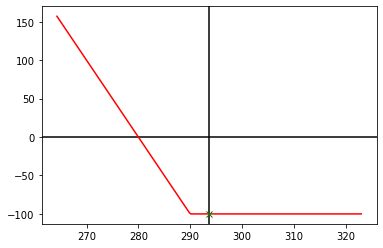

In [11]:
B.positions[0].printProps()


        ----------------------------------------
        Asset: AAPL
        Positions type: Sell
        Opening Date: 2019-12-31 00:00:00
        Underlying value: 293.6499938964844
        Position value: -29364.999389648438
        Amount: 100
        Price paid: -28364.999389648438
        Strike price: None
        Absolute return: -1000.0
        Percentage return: 0.0352547160767767
        Log return: -inf
        Currently closed: False
        ----------------------------------------
        


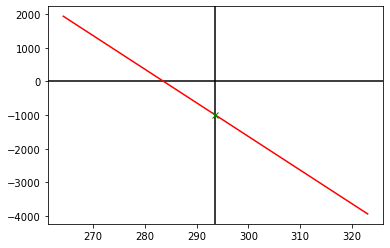

In [12]:
B.positions[1].printProps()

In [13]:
pos = B.positions[1]
B.placeOrder(pos.getClosingOrder())

In [14]:
B.orders

In [15]:
B.processOrders()

Closing Order is beeing processed


In [17]:
B.orders

[]